In [ ]:
!pip install librosa matplotlib numpy tensorflow

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def load_fsdd_by_digit(data_dir, sample_rate=16000, n_mels=64, max_files_per_digit=200):
    data = []
    labels = []
    for digit in range(10):
        files = [f for f in os.listdir(data_dir) if f.startswith(f"{digit}_") and f.endswith('.wav')][:max_files_per_digit]
        for file in files:
            path = os.path.join(data_dir, file)
            y, sr = librosa.load(path, sr=sample_rate)
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
            S_dB = librosa.power_to_db(S, ref=np.max)
            S_dB = librosa.util.fix_length(S_dB, size=64, axis=1)
            S_dB = S_dB[:64, :]
            S_dB = (S_dB + 80) / 80
            S_dB = np.expand_dims(S_dB, axis=-1)
            data.append(S_dB)
            labels.append(digit)
    return np.array(data), np.array(labels)


In [ ]:
from tensorflow.keras.utils import to_categorical

data, labels = load_fsdd_by_digit('/content/drive/MyDrive/Colab Notebooks/recordings')
labels_onehot = to_categorical(labels, num_classes=10)


In [ ]:
def build_conditional_generator(latent_dim, label_dim, output_shape):
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(label_dim,))

    x = layers.Concatenate()([noise_input, label_input])
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(np.prod(output_shape), activation='tanh')(x)
    output = layers.Reshape(output_shape)(x)

    return models.Model([noise_input, label_input], output)


In [ ]:
def build_conditional_discriminator(input_shape, label_dim):
    spectrogram_input = layers.Input(shape=input_shape)
    label_input = layers.Input(shape=(label_dim,))

    x = layers.Flatten()(spectrogram_input)
    x = layers.Concatenate()([x, label_input])

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    return models.Model([spectrogram_input, label_input], output)


In [ ]:
latent_dim = 100
label_dim = 10
output_shape = (64, 64, 1)

generator = build_conditional_generator(latent_dim, label_dim, output_shape)
discriminator = build_conditional_discriminator(output_shape, label_dim)

discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# CGAN model
noise_input = layers.Input(shape=(latent_dim,))
label_input = layers.Input(shape=(label_dim,))
generated_image = generator([noise_input, label_input])
discriminator.trainable = False
validity = discriminator([generated_image, label_input])
cgan = models.Model([noise_input, label_input], validity)
cgan.compile(optimizer='adam', loss='binary_crossentropy')


In [ ]:
def train_cgan(generator, discriminator, cgan, data, labels, latent_dim, epochs=1000, batch_size=32):
    half_batch = batch_size // 2
    for epoch in range(epochs):
        idx = np.random.randint(0, data.shape[0], half_batch)
        real_samples = data[idx]
        real_labels = labels[idx]

        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_labels = to_categorical(np.random.randint(0, 10, half_batch), num_classes=10)
        fake_samples = generator.predict([noise, fake_labels])

        d_loss_real = discriminator.train_on_batch([real_samples, real_labels], np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch([fake_samples, fake_labels], np.zeros((half_batch, 1)))

        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        sampled_labels = to_categorical(np.random.randint(0, 10, batch_size), num_classes=10)
        g_loss = cgan.train_on_batch([noise, sampled_labels], np.ones((batch_size, 1)))

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | D loss: {d_loss_real[0] + d_loss_fake[0]:.4f} | G loss: {g_loss:.4f}")

In [ ]:
latent_dim = 100
label_dim = 10
output_shape = (64, 64, 1)

generator = build_conditional_generator(latent_dim, label_dim, output_shape)
discriminator = build_conditional_discriminator(output_shape, label_dim)
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# CGAN model
noise_input = layers.Input(shape=(latent_dim,))
label_input = layers.Input(shape=(label_dim,))
generated_image = generator([noise_input, label_input])
discriminator.trainable = False
validity = discriminator([generated_image, label_input])
cgan = models.Model([noise_input, label_input], validity)
cgan.compile(optimizer='adam', loss='binary_crossentropy')


In [ ]:
# Huấn luyện
train_cgan(generator, discriminator, cgan, data, labels_onehot, latent_dim=100, epochs=1000, batch_size=32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D loss: 1.0900 | G loss: 0.5479
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━

In [ ]:
def generate_digit_spectrogram(generator, digit, latent_dim=100):
    noise = np.random.normal(0, 1, (1, latent_dim))
    label = to_categorical([digit], num_classes=10)
    generated = generator.predict([noise, label])

    plt.imshow(generated[0].squeeze(), aspect='auto', origin='lower', cmap='magma')
    plt.title(f"Spectrogram giả cho số {digit}")
    plt.axis('on')
    plt.show()


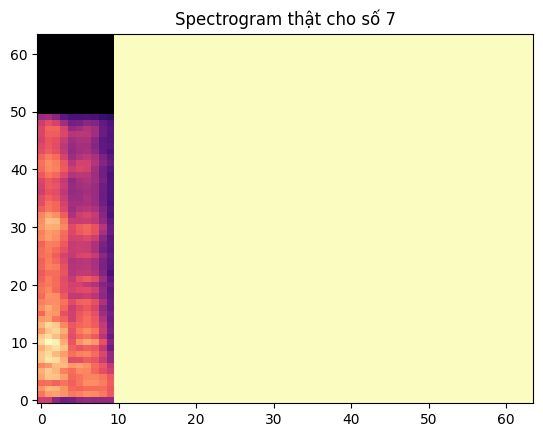

In [ ]:
index_data = 1500
plt.imshow(data[index_data].squeeze(), aspect='auto', origin='lower', cmap='magma')
plt.title(f"Spectrogram thật cho số {labels[index_data]}")
plt.axis('on')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


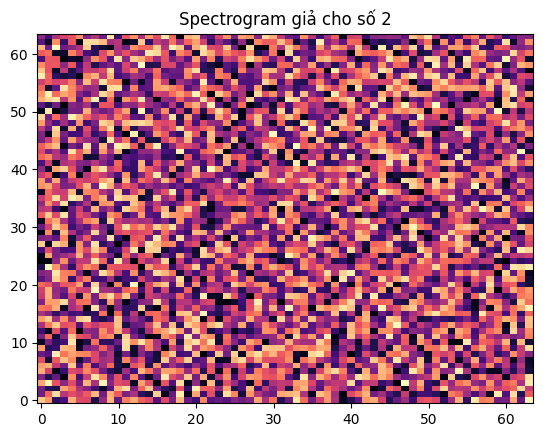

In [ ]:
generate_digit_spectrogram(generator, digit=2)
